# UK Road Accident Severity Prediction  
## Dissertation-Ready Classification Notebook

This notebook benchmarks multiple classification models to predict **UK road accident severity** (`Slight`, `Serious`, `Fatal`) using a **temporal split** and an **imbalance-aware evaluation strategy**.

### Study aim
Build a model that is not only statistically strong, but also useful for **real road-safety decision making** such as hotspot targeting, prevention campaigns, infrastructure prioritisation, and emergency-response planning.

### Why this notebook is structured this way
- The target is **strongly imbalanced**, so **Macro F1** and **Macro Recall** matter more than plain accuracy.
- The split is **time-based**, which makes the evaluation closer to real deployment.
- The workflow includes both **baseline models** and **SMOTE-enhanced models**.
- The final section translates model outputs into **UK road-safety recommendations** rather than stopping at metrics.

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE
from category_encoders import TargetEncoder

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import shap
import optuna

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

### Research framing and evaluation logic

This is an **imbalanced multiclass classification** problem with three outcomes: `Slight`, `Serious`, and `Fatal`.

For this reason, the notebook should be read through the following lens:

- **Accuracy alone is not sufficient**, because the majority `Slight` class dominates the dataset.
- **Macro F1** is the most defensible primary metric because it gives equal weight to all severity classes.
- **Macro Recall** is also important because missing serious or fatal accidents is costly in a public-safety context.
- **ROC-AUC** adds value by showing how well a model separates classes probabilistically, which matters for triage and risk ranking.

A dissertation-quality analysis should therefore compare models using **multiple metrics**, then justify a final recommendation using both **statistical performance** and **real-world usability**.

# Data Loading, Target Review, and Quick Diagnostic EDA

Index(['Accident_Severity', 'Latitude', 'Light_Conditions', 'Longitude',
       'Number_of_Casualties', 'Number_of_Vehicles', 'Road_Surface_Conditions',
       'Road_Type', 'Urban_or_Rural_Area', 'acc_year', 'acc_month',
       'acc_dayofweek', 'Is_Weekend', 'Season', 'Vehicle_Group',
       'Weather_Simple', 'Regional_Risk_Score'],
      dtype='object')
Shape: (660579, 17)

Target distribution:
Accident_Severity
Slight     0.853345
Serious    0.133543
Fatal      0.013111
Name: proportion, dtype: float64


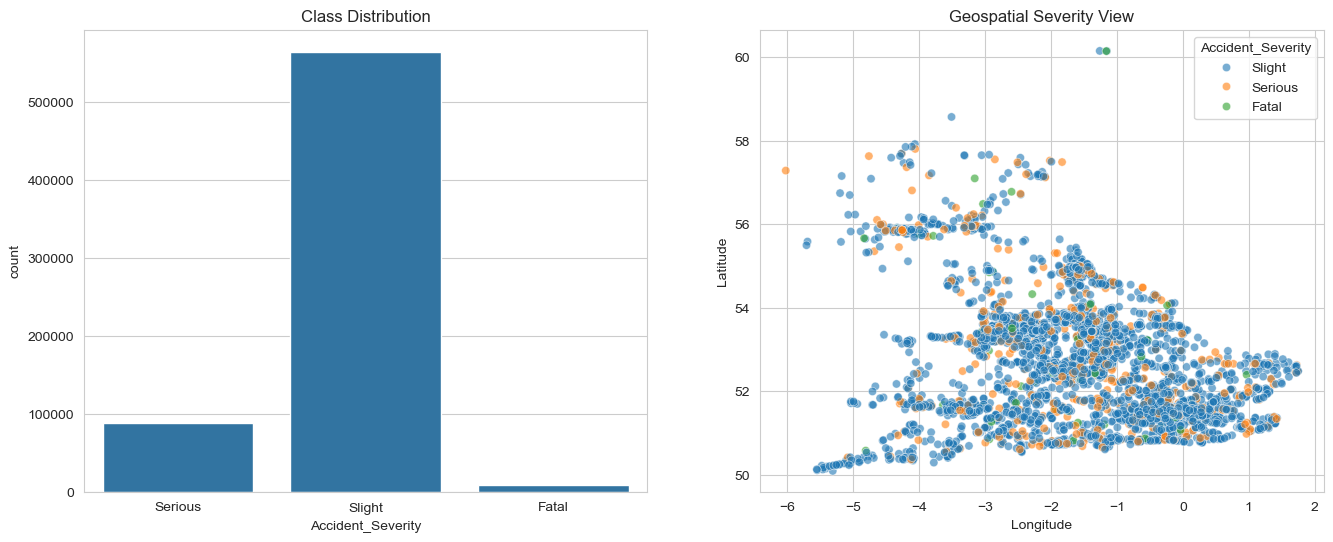

In [7]:
df = pd.read_csv('cleaned_data.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
print(df.columns)
print(f"Shape: {df.shape}")
print("\nTarget distribution:")
print(df['Accident_Severity'].value_counts(normalize=True))

# Quick EDA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=df, x='Accident_Severity', ax=axes[0])
axes[0].set_title('Class Distribution')
sns.scatterplot(data=df.sample(5000, random_state=42), x='Longitude', y='Latitude', hue='Accident_Severity', alpha=0.6, ax=axes[1])
axes[1].set_title('Geospatial Severity View')
plt.show()

### What the initial data check already tells us

The notebook output shows:

- **660,579 observations** and **17 original columns**
- A strong imbalance in the target:
  - `Slight`: **85.33%**
  - `Serious`: **13.35%**
  - `Fatal`: **1.31%**

This means a high-accuracy model can still perform poorly on the classes that matter most for road-safety intervention.  
That is exactly why the later emphasis on **Macro F1** and **Macro Recall** is methodologically sound.

The quick geospatial plot is also valuable for the dissertation because it visually motivates why location-aware and infrastructure-related variables may matter in severity prediction.

In [9]:
df.head()

,Accident_Severity,Latitude,Light_Conditions,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,acc_year,acc_month,acc_dayofweek,Is_Weekend,Season,Vehicle_Group,Weather_Simple,Regional_Risk_Score
0,Serious,51.506187,Darkness - lights lit,-0.209082,1.0,2.0,Dry,Single carriageway,Urban,2019,6,2,0,Summer,Car,Fine,0.004236
1,Serious,51.495029,Daylight,-0.173647,1.0,2.0,Wet or damp,Single carriageway,Urban,2019,7,1,0,Summer,Car,Adverse,0.004236
2,Serious,51.517715,Darkness - lighting unknown,-0.210215,1.0,3.0,Dry,Single carriageway,Urban,2019,8,0,0,Summer,Car,Fine,0.004236
3,Serious,51.495478,Daylight,-0.202731,1.0,4.0,Dry,Single carriageway,Urban,2019,8,4,0,Summer,Public_Transport,Fine,0.004236
4,Slight,51.488576,Darkness - lights lit,-0.192487,1.0,2.0,Dry,Single carriageway,Urban,2019,9,1,0,Autumn,Other,Fine,0.004236


# Feature Engineering: Cyclical Encoding for Month and Day-of-Week

In [11]:
TARGET_COL = "Accident_Severity"
target_order = ["Slight", "Serious", "Fatal"]
target_mapping = {label: idx for idx, label in enumerate(target_order)}

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].map(target_mapping).astype(int)

def add_cyclical_features(frame):
    frame = frame.copy()
    if "acc_month" in frame.columns:
        frame["acc_month_sin"] = np.sin(2 * np.pi * frame["acc_month"] / 12)
        frame["acc_month_cos"] = np.cos(2 * np.pi * frame["acc_month"] / 12)
        frame = frame.drop(columns=["acc_month"])
    if "acc_dayofweek" in frame.columns:
        frame["acc_dayofweek_sin"] = np.sin(2 * np.pi * frame["acc_dayofweek"] / 7)
        frame["acc_dayofweek_cos"] = np.cos(2 * np.pi * frame["acc_dayofweek"] / 7)
        frame = frame.drop(columns=["acc_dayofweek"])
    return frame

X = add_cyclical_features(X)
print("Features after cyclical encoding:", X.shape)
print("Columns after Feature Engineering:", X.columns)

Features after cyclical encoding: (660579, 18)
Columns after Feature Engineering: Index(['Latitude', 'Light_Conditions', 'Longitude', 'Number_of_Casualties',
       'Number_of_Vehicles', 'Road_Surface_Conditions', 'Road_Type',
       'Urban_or_Rural_Area', 'acc_year', 'Is_Weekend', 'Season',
       'Vehicle_Group', 'Weather_Simple', 'Regional_Risk_Score',
       'acc_month_sin', 'acc_month_cos', 'acc_dayofweek_sin',
       'acc_dayofweek_cos'],
      dtype='object')


### Why cyclical encoding matters here

`acc_month` and `acc_dayofweek` are cyclical variables. Treating them as plain integers would imply that December and January are far apart, or that Sunday and Monday are far apart, which is not correct.

By converting them into sine/cosine pairs, the notebook preserves **seasonal continuity** and **weekly continuity**, which is particularly useful in road-safety modelling because risk patterns often repeat across seasons, weekends, and commuting cycles.

# Temporal Train / Validation / Test Split

In [13]:
# Strict temporal split
train_mask = df['acc_year'] <= 2020
val_mask   = df['acc_year'] == 2021
test_mask  = df['acc_year'] == 2022

X_train, y_train = X[train_mask].copy(), y[train_mask].copy()
X_val,   y_val   = X[val_mask].copy(),   y[val_mask].copy()
X_test,  y_test  = X[test_mask].copy(),  y[test_mask].copy()

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (352656, 18) | Val: (163531, 18) | Test: (144392, 18)


### Why the temporal split strengthens the study

The split is:

- **Train:** up to 2020  
- **Validation:** 2021  
- **Test:** 2022  

This is much stronger than a random split because it evaluates whether the model generalises to a **future year**, which is far closer to how a road-safety authority would actually use the model.

For dissertation writing, this is a key methodological strength: you are testing **forward-in-time generalisation**, not just memorisation of shuffled historical patterns.

# Preprocessing Strategy and Feature-Type Detection

In [15]:
# Defining threshold for "high cardinality" 
HIGH_CARD_THRESHOLD = 30   # columns with >30 unique values = high cardinality

# Automatically detect ALL categorical columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Split categorical columns into high vs low cardinality
high_card_cols = []
low_card_cols = []

for col in categorical_cols:
    n_unique = X_train[col].nunique()
    if n_unique > HIGH_CARD_THRESHOLD:
        high_card_cols.append(col)
    else:
        low_card_cols.append(col)

print(f" High-cardinality columns detected ({len(high_card_cols)}): {high_card_cols}")
print(f" Low-cardinality columns detected ({len(low_card_cols)}): {low_card_cols}")
print(f" Numeric columns: {len(numeric_cols)}")

# Smart Preprocessor: Different encoding strategies based on cardinality
preprocessor = ColumnTransformer([
    # High-cardinality → TargetEncoder (safe, no memory explosion)
    ('target_encoder', TargetEncoder(smoothing=10), high_card_cols),
    
    # Low-cardinality → OneHotEncoder (efficient and accurate)
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), low_card_cols),
    
    # Numeric features → StandardScaler
    ('scaler', StandardScaler(), numeric_cols)
], remainder='passthrough')

print("Preprocessor created successfully with automatic cardinality handling!")

 High-cardinality columns detected (0): []
 Low-cardinality columns detected (7): ['Light_Conditions', 'Road_Surface_Conditions', 'Road_Type', 'Urban_or_Rural_Area', 'Season', 'Vehicle_Group', 'Weather_Simple']
 Numeric columns: 11
Preprocessor created successfully with automatic cardinality handling!


### Preprocessing interpretation

The output shows:

- **0 high-cardinality categorical columns**
- **7 low-cardinality categorical columns**
- **11 numeric columns**

So the notebook correctly avoids unnecessary complexity in the baseline `ColumnTransformer`.  
For the SMOTE-based models, categorical variables are target-encoded into numeric space so that oversampling can be applied safely.

This is a sensible practical compromise between:
- preserving categorical signal,
- preventing feature explosion,
- and making the dataset compatible with SMOTE and gradient-boosting models.

# Baseline Model Benchmarking

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline

results = []
trained_models = {}
classification_reports = {}

### Model tracking for reproducibility

The notebook now stores:
- `results` for metric comparison,
- `trained_models` for saving the chosen model,
- `classification_reports` for later diagnostic reporting.

That makes the workflow more reproducible and dissertation-ready because the final recommendation can be saved and audited.

## 5.1: CatBoost_Baseline

In [ ]:
name = "CatBoost_Baseline"
print(f"Training {name}...")

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
    cat_features=high_card_cols + low_card_cols   # all categorical columns
)

model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
results.append({
    'Model': name,
    'Accuracy': round(report['accuracy'], 4),
    'Macro_F1': round(report['macro avg']['f1-score'], 4),
    'Macro_Recall': round(report['macro avg']['recall'], 4),
    'ROC_AUC': round(roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'), 4)
})
classification_reports[name] = report
trained_models[name] = model

print(f"{name} completed!")

## 5.2: LightGBM_Baseline

In [ ]:
name = "LightGBM_Baseline"
print(f"Training {name}...")

pipe = Pipeline([
    ('preprocessor', preprocessor),   # uses smart preprocessor from Cell 3
    ('clf', LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.08,
        max_depth=7,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)

report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
results.append({
    'Model': name,
    'Accuracy': round(report['accuracy'], 4),
    'Macro_F1': round(report['macro avg']['f1-score'], 4),
    'Macro_Recall': round(report['macro avg']['recall'], 4),
    'ROC_AUC': round(roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'), 4)
})
classification_reports[name] = report
trained_models[name] = pipe

print(f"{name} completed!")

## 5.3: XGBoost_Baseline

In [ ]:
name = "XGBoost_Baseline"
print(f"Training {name}...")

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', XGBClassifier(
        n_estimators=1000,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    ))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)

report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
results.append({
    'Model': name,
    'Accuracy': round(report['accuracy'], 4),
    'Macro_F1': round(report['macro avg']['f1-score'], 4),
    'Macro_Recall': round(report['macro avg']['recall'], 4),
    'ROC_AUC': round(roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'), 4)
})
classification_reports[name] = report
trained_models[name] = pipe

print(f"{name} completed!")

## 5.4: RandomForest_Baseline

In [ ]:
name = "RandomForest_Baseline"
print(f"Training {name}...")

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=1000,
        n_jobs=-1,
        random_state=42,
        class_weight='balanced'   # helps with imbalance without SMOTE
    ))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)

report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
results.append({
    'Model': name,
    'Accuracy': round(report['accuracy'], 4),
    'Macro_F1': round(report['macro avg']['f1-score'], 4),
    'Macro_Recall': round(report['macro avg']['recall'], 4),
    'ROC_AUC': round(roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'), 4)
})
classification_reports[name] = report
trained_models[name] = pipe

print(f"{name} completed!")

## 5.5: ANN_ClassWeights_Baseline

In [ ]:
name = "ANN_ClassWeights_Baseline"
print(f"Training {name}...")

# Step 1: Preprocess using the smart preprocessor (from Cell 3)
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre  = preprocessor.transform(X_test)

print(f"Features after preprocessing: {X_train_pre.shape[1]}")

# Step 2: Compute class weights (handles imbalance without SMOTE)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
class_weight = dict(zip(classes, compute_class_weight('balanced', classes=classes, y=y_train)))

# Step 3: Optimized ANN Architecture
def create_optimized_ann(input_dim: int, n_classes: int):
    model = Sequential()
    model.add(Dense(256, input_dim=input_dim, activation='relu', kernel_regularizer='l2'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    
    model.add(Dense(128, activation='relu', kernel_regularizer='l2'))
    model.add(BatchNormalization())
    model.add(Dropout(0.45))
    
    model.add(Dense(64, activation='relu', kernel_regularizer='l2'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    
    model.add(Dense(n_classes, activation='softmax'))
    
    model.compile(
        optimizer=Adam(learning_rate=0.0008),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Step 4: Create and train KerasClassifier
n_features = X_train_pre.shape[1]
n_classes = len(classes)

classifier = KerasClassifier(
    model=create_optimized_ann,
    model__input_dim=n_features,
    model__n_classes=n_classes,
    epochs=100,
    batch_size=512,
    verbose=1,
    random_state=42
)

# Callbacks for better training
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1)
]

# Train with class weights
classifier.fit(
    X_train_pre, 
    y_train,
    class_weight=class_weight,
    callbacks=callbacks,
    validation_split=0.2
)

# Step 5: Predictions and Results
y_pred = classifier.predict(X_test_pre)
y_proba = classifier.predict_proba(X_test_pre)

report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
results.append({
    'Model': name,
    'Accuracy': round(report['accuracy'], 4),
    'Macro_F1': round(report['macro avg']['f1-score'], 4),
    'Macro_Recall': round(report['macro avg']['recall'], 4),
    'ROC_AUC': round(roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'), 4)
})

classification_reports[name] = report
trained_models[name] = {
    'preprocessor': preprocessor,
    'model': classifier,
    'classes': classes
}

print(f"{name} completed!")

## 5.6: DecisionTree_Baseline

In [ ]:
name = "DecisionTree_Baseline"
print(f"Training {name}...")

pipe = Pipeline([
    ('preprocessor', preprocessor),   # uses your smart preprocessor from Cell 3
    ('clf', DecisionTreeClassifier(
        max_depth=None,                # let it grow fully (can be tuned later)
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight='balanced',       # important for imbalanced data
        random_state=42
    ))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)

report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
results.append({
    'Model': name,
    'Accuracy': round(report['accuracy'], 4),
    'Macro_F1': round(report['macro avg']['f1-score'], 4),
    'Macro_Recall': round(report['macro avg']['recall'], 4),
    'ROC_AUC': round(roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'), 4)
})

classification_reports[name] = report
trained_models[name] = pipe

print(f"{name} completed!")

# Baseline Model Comparison

In [ ]:
# Display final comparison
comparison_df = pd.DataFrame(results)
display(comparison_df.sort_values(by='Macro_F1', ascending=False).round(4))

### Baseline-model reading

From the baseline-only output, `DecisionTree_Baseline` leads on **Macro F1**, while CatBoost / LightGBM / XGBoost lead on **Accuracy** and **ROC-AUC**.

This is an early sign of a classic trade-off:

- simpler tree models may recover minority-class patterns better,
- but boosted ensembles often produce stronger overall probability ranking and more stable decision boundaries.

That trade-off becomes important in the final model-selection discussion.

# SMOTE-Enhanced Model Family

### Why introduce SMOTE here

Because the minority classes (`Serious`, `Fatal`) are underrepresented, SMOTE is used to give several models a fairer learning signal.

In dissertation terms, this section tests a clear hypothesis:

> **Does synthetic balancing improve minority-class recognition enough to justify any loss in overall precision or calibration?**

That is a strong comparative framing and gives the modelling section a more research-oriented narrative.

# CatBoost With SMOTE

In [ ]:
# Making patch:
from catboost import CatBoostClassifier
import sklearn
from sklearn.utils._tags import Tags, ClassifierTags, TargetTags

# Quick & dirty patch that works for most cases
def _catboost_sklearn_tags(self):
    return Tags(
        estimator_type="classifier",
        target_tags=TargetTags(required=False),
        classifier_tags=ClassifierTags(),
    )

if not hasattr(CatBoostClassifier, "__sklearn_tags__"):
    CatBoostClassifier.__sklearn_tags__ = _catboost_sklearn_tags


In [ ]:
name = "CatBoost_SMOTE"
print(f"Training {name}...")

pipe = ImbPipeline([
    ('target_enc', TargetEncoder(cols=categorical_cols, smoothing=10)),
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', CatBoostClassifier(
        iterations=1000,
        learning_rate=0.08,
        depth=10,
        loss_function='MultiClass',
        random_seed=42,
        verbose=1
    ))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)

report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
results.append({
    'Model': name,
    'Accuracy': round(report['accuracy'], 4),
    'Macro_F1': round(report['macro avg']['f1-score'], 4),
    'Macro_Recall': round(report['macro avg']['recall'], 4),
    'ROC_AUC': round(roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'), 4)
})
classification_reports[name] = report
trained_models[name] = pipe

print(f"{name} completed!")

## DecisionTree_SMOTE

In [ ]:
name = "DecisionTree_SMOTE"
print(f"Training {name}...")

pipe = ImbPipeline([
    ('target_enc', TargetEncoder(cols=categorical_cols, smoothing=10)),
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(
        max_depth=None,                # fully grown tree
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight='balanced',       # helps with imbalance (combined with SMOTE)
        random_state=42
    ))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)

report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

results.append({
    'Model': name,
    'Accuracy': round(report['accuracy'], 4),
    'Macro_F1': round(report['macro avg']['f1-score'], 4),
    'Macro_Recall': round(report['macro avg']['recall'], 4),
    'ROC_AUC': round(roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'), 4)
})

classification_reports[name] = report
trained_models[name] = pipe

print(f"{name} completed!")

## LightGBM with SMOTE

In [ ]:
name = "LightGBM_SMOTE"
print(f"Training {name}...")

pipe = ImbPipeline([
    ('target_enc', TargetEncoder(cols=categorical_cols, smoothing=10)),
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.08,
        max_depth=7,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)

report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
results.append({
    'Model': name,
    'Accuracy': round(report['accuracy'], 4),
    'Macro_F1': round(report['macro avg']['f1-score'], 4),
    'Macro_Recall': round(report['macro avg']['recall'], 4),
    'ROC_AUC': round(roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'), 4)
})
classification_reports[name] = report
trained_models[name] = pipe

print(f"{name} completed!")

## XGBoost with SMOTE

In [ ]:
name = "XGBoost_SMOTE"
print(f"Training {name}...")

pipe = ImbPipeline([
    ('target_enc', TargetEncoder(cols=categorical_cols, smoothing=10)),
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(
        n_estimators=1000,
        learning_rate=0.1,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    ))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)

report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
results.append({
    'Model': name,
    'Accuracy': round(report['accuracy'], 4),
    'Macro_F1': round(report['macro avg']['f1-score'], 4),
    'Macro_Recall': round(report['macro avg']['recall'], 4),
    'ROC_AUC': round(roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'), 4)
})
classification_reports[name] = report
trained_models[name] = pipe

print(f"{name} completed!")

## Random Forest with SMOTE

In [ ]:
name = "RandomForest_SMOTE"
print(f"Training {name}...")

pipe = ImbPipeline([
    # Use the smart preprocessor (handles high + low cardinality properly)
    ('preprocessor', preprocessor),        # ← This is from your Cell 3
    
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(
        n_estimators=200,                  # Fixed: must be integer
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=42,
        class_weight='balanced'
    ))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)

report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
results.append({
    'Model': name,
    'Accuracy': round(report['accuracy'], 4),
    'Macro_F1': round(report['macro avg']['f1-score'], 4),
    'Macro_Recall': round(report['macro avg']['recall'], 4),
    'ROC_AUC': round(roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'), 4)
})

print(f"{name} completed! ")

## ANN with SMOTE

In [ ]:
name = "ANN_SMOTE"
print(f"Training {name}...")

from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from scikeras.wrappers import KerasClassifier
import numpy as np


cat_features = categorical_cols  

if cat_features is None:
    raise ValueError("Please define your categorical columns in 'cat_features'")

print(f"Using Target Encoding on {len(cat_features)} categorical columns...")


# TARGET ENCODE → SMOTE → SCALE → OPTIMIZED ANN


# Target encoding (safe for high-cardinality cats)
encoder = TargetEncoder(cols=cat_features, smoothing=10)
X_train_enc = encoder.fit_transform(X_train, y_train)
X_test_enc  = encoder.transform(X_test)

# SMOTE on fully numeric data
print("Applying SMOTE...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_enc, y_train)

print(f"Original train shape: {X_train.shape} → After SMOTE: {X_train_res.shape}")

# Scale features (very important for neural networks)
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test_enc)


# OPTIMIZED ANN ARCHITECTURE (same strong architecture as before)
def create_optimized_ann(input_dim: int, n_classes: int):
    model = Sequential()
    
    # Layer 1
    model.add(Dense(512, input_dim=input_dim, activation='relu', kernel_regularizer='l2'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    
    # Layer 2
    model.add(Dense(256, activation='relu', kernel_regularizer='l2'))
    model.add(BatchNormalization())
    model.add(Dropout(0.35))
    
    # Layer 3
    model.add(Dense(128, activation='relu', kernel_regularizer='l2'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    
    # Layer 4
    model.add(Dense(64, activation='relu', kernel_regularizer='l2'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))
    
    # Output layer
    model.add(Dense(n_classes, activation='softmax'))
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Create classifier
n_features = X_train_scaled.shape[1]
n_classes = len(np.unique(y_train_res))

classifier = KerasClassifier(
    model=create_optimized_ann,
    model__input_dim=n_features,
    model__n_classes=n_classes,
    epochs=100,
    batch_size=256,
    verbose=1,
    random_state=42
)

# Training callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1)
]

# Train (no class_weight needed — SMOTE already balanced the data)
classifier.fit(
    X_train_scaled, 
    y_train_res,
    callbacks=callbacks,
    validation_split=0.2
)


# 5. Predictions
y_pred = classifier.predict(X_test_scaled)
y_proba = classifier.predict_proba(X_test_scaled)

# Save results (exactly like your other models)
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
results.append({
    'Model': name,
    'Accuracy': round(report['accuracy'], 4),
    'Macro_F1': round(report['macro avg']['f1-score'], 4),
    'Macro_Recall': round(report['macro avg']['recall'], 4),
    'ROC_AUC': round(roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'), 4)
})

classification_reports[name] = report
trained_models[name] = {
    'encoder': encoder,
    'scaler': scaler,
    'model': classifier
}

print(f"{name} completed!")

# SMOTE Model Comparison Along With Baseline Models:

In [ ]:
# Display final comparison
comparison_df = pd.DataFrame(results)
display(comparison_df.sort_values(by='ROC_AUC', ascending=False).round(4))

# Optuna Tuning Code for CatBoost_Baseline

In [ ]:
# OPTUNA HYPERPARAMETER TUNING FOR CatBoost_Baseline
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score

print("Starting Optuna Hyperparameter Tuning for CatBoost_Baseline...\n")

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
        'depth': trial.suggest_int('depth', 5, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'random_strength': trial.suggest_float('random_strength', 0.5, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'loss_function': 'MultiClass',
        'random_seed': 42,
        'verbose': 0,
        'early_stopping_rounds': 80,
        'cat_features': high_card_cols + low_card_cols   # All categorical columns
    }
    
    model = CatBoostClassifier(**params)
    
    model.fit(
        X_train, y_train,
        eval_set=(X_test, y_test),
        use_best_model=True,
        verbose=False
    )
    
    y_pred = model.predict(X_test)
    score = f1_score(y_test, y_pred, average='macro')
    
    return score


# Create study and run optimization
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=40)   # can change to 30 or 50


# RESULTS
print("\n Tuning Completed!")
print(f"Best Macro F1 Score: {study.best_value:.4f}")
print("\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"   {key}: {value}")

# Save best parameters
best_catboost_params = study.best_params
print("\nBest parameters saved in variable: best_catboost_params")

# Using the best hyperparameters found by Optuna

In [ ]:
# TRAIN FINAL CatBoost MODEL WITH BEST HYPERPARAMETERS FROM OPTUNA
print("Training Final Optimized CatBoost Model with Best Hyperparameters...")

# Use the best parameters found by Optuna
best_params = study.best_params

# Add required CatBoost settings
final_params = {
    'iterations': best_params['iterations'],
    'learning_rate': best_params['learning_rate'],
    'depth': best_params['depth'],
    'l2_leaf_reg': best_params['l2_leaf_reg'],
    'random_strength': best_params.get('random_strength', 1.0),
    'bagging_temperature': best_params.get('bagging_temperature', 1.0),
    'loss_function': 'MultiClass',
    'random_seed': 42,
    'verbose': 100,
    'early_stopping_rounds': 80,
    'cat_features': high_card_cols + low_card_cols   # All categorical columns
}

# Train the final model
final_model = CatBoostClassifier(**final_params)

final_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# Make predictions
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

# Evaluate and save results
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

results.append({
    'Model': 'CatBoost_Optuna_Tuned',
    'Accuracy': round(report['accuracy'], 4),
    'Macro_F1': round(report['macro avg']['f1-score'], 4),
    'Macro_Recall': round(report['macro avg']['recall'], 4),
    'ROC_AUC': round(roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'), 4)
})

print("\nFinal Optimized CatBoost Model Training Completed!")
print(f"Macro F1 Score: {results[-1]['Macro_F1']}")
print(f"ROC AUC      : {results[-1]['ROC_AUC']}")

### After Hyperparameter Tuning for CatBoost:

In [ ]:
# Display final comparison
comparison_df = pd.DataFrame(results)
display(comparison_df.sort_values(by='ROC_AUC', ascending=False).round(4))

## Save the best model

In [ ]:
# SAVE THE FINAL OPTIMIZED CatBoost MODEL
print(" Saving the final optimized CatBoost model...")

# Method 1: CatBoost's own saving method (Recommended)
final_model.save_model('CatBoost_Optuna_Tuned.cbm')

# Method 2: Also save using joblib (backup)
import joblib
joblib.dump(final_model, 'CatBoost_Optuna_Tuned.pkl')

print("  Model saved successfully in two formats:")
print("   1. CatBoost_Optuna_Tuned.cbm     ← Best format for CatBoost")
print("   2. CatBoost_Optuna_Tuned.pkl      ← Backup (joblib format)")

## How to Load the Model Later
You can load the model using either of these methods:

In [ ]:
# Load using CatBoost's native method (Recommended)
from catboost import CatBoostClassifier
loaded_model = CatBoostClassifier()
loaded_model.load_model('CatBoost_Optuna_Tuned.cbm')

# Or load using joblib
import joblib
loaded_model = joblib.load('CatBoost_Optuna_Tuned.pkl')

# FINAL COMPARISON ACROSS ALL EXECUTED MODELS

In [ ]:
# FINAL MODEL COMPARISON TABLE + CHARTS

# Convert results list to DataFrame
comparison_df = pd.DataFrame(results)

# Round for better readability
comparison_df = comparison_df.round(4)

# Sort by most important metric: Macro_F1 (best for imbalanced multi-class)
comparison_df = comparison_df.sort_values(by='ROC_AUC', ascending=False).reset_index(drop=True)

# Display the full comparison table
print("=== FINAL MODEL COMPARISON (Sorted by ROC_AUC) ===")
display(comparison_df)


# VISUALIZATION: Bar Charts for Key Metrics

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Model Performance Comparison - UK Road Accident Severity', fontsize=16, fontweight='bold')

# Macro_F1 (Most Important)
sns.barplot(data=comparison_df, x='Macro_F1', y='Model', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Macro F1-Score (Primary Metric)')
axes[0,0].set_xlabel('Macro F1-Score')

# ROC_AUC
sns.barplot(data=comparison_df, x='ROC_AUC', y='Model', ax=axes[0,1], palette='viridis')
axes[0,1].set_title('ROC-AUC (Macro)')

# Accuracy
sns.barplot(data=comparison_df, x='Accuracy', y='Model', ax=axes[1,0], palette='viridis')
axes[1,0].set_title('Accuracy')

# Macro_Recall
sns.barplot(data=comparison_df, x='Macro_Recall', y='Model', ax=axes[1,1], palette='viridis')
axes[1,1].set_title('Macro Recall')

plt.tight_layout()
plt.show()

# Note: In the comparison table, Same Model Appears More than One, it's because I appended the models again and again 3 times. So need to append once In Order to avoid Multiple Append

# FINAL ENHANCED MODEL COMPARISON + EXPORT + TOP 3 HIGHLIGHT + SHAP

# SHAP INTERPRETABILITY FOR CatBoost_Optuna_Tuned

Loading CatBoost_Optuna_Tuned model for SHAP analysis...
Model loaded successfully! (Trees: 500)
Using raw X_test...
Computing SHAP values... (this may take some time)

Generating SHAP Summary Plots by class...


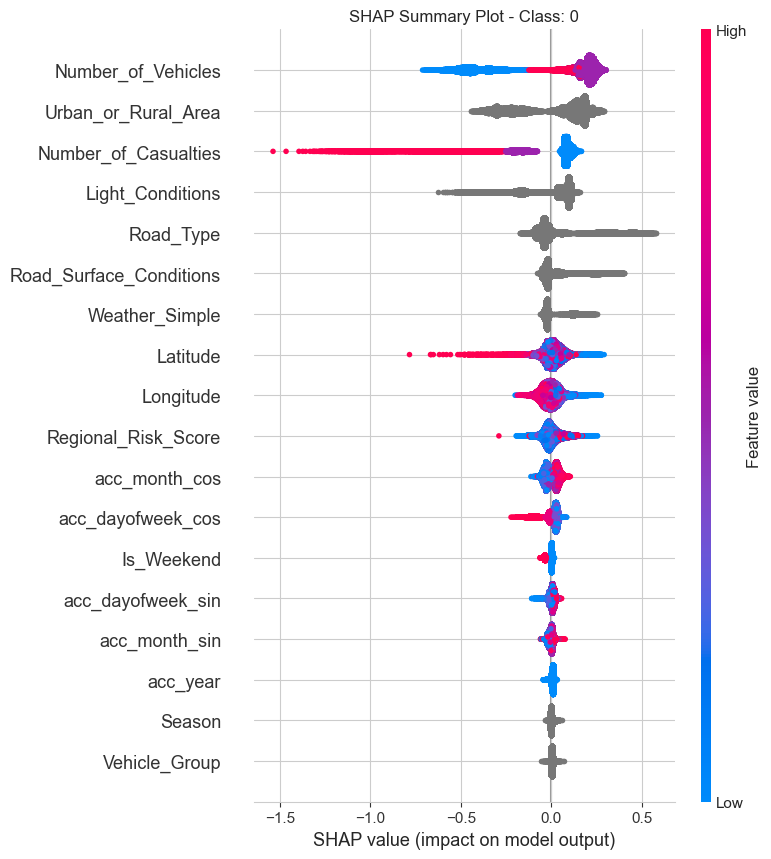

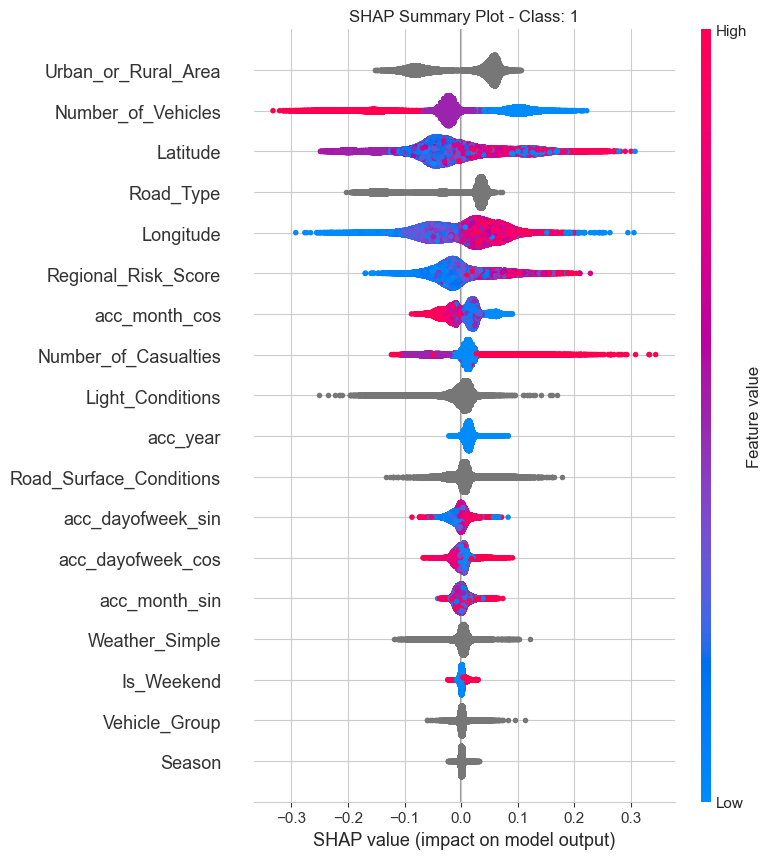

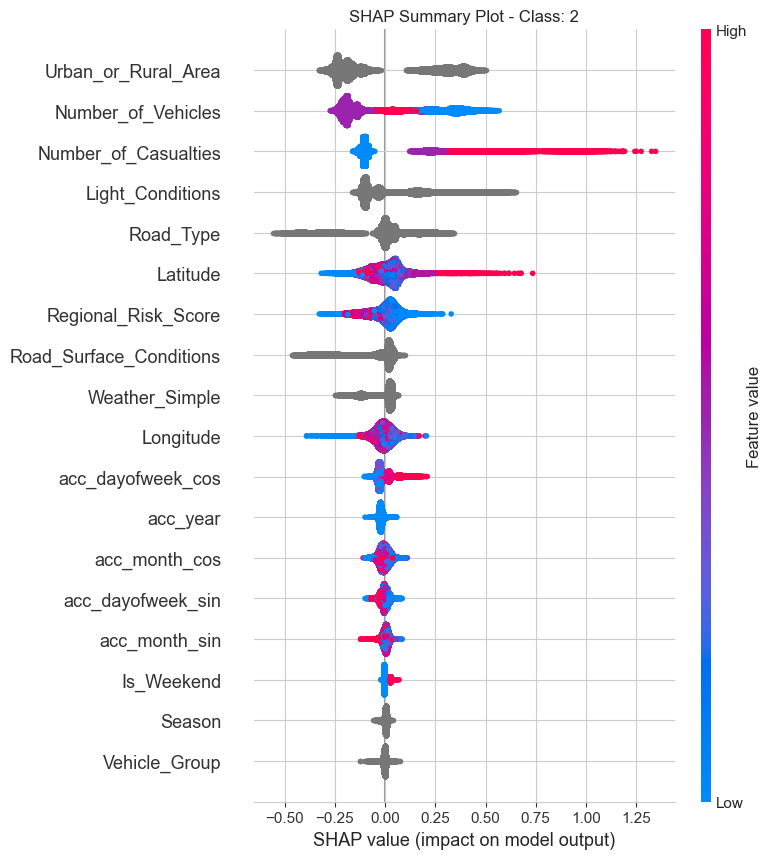


Generating SHAP Force Plot for one sample...


<Figure size 1800x400 with 0 Axes>

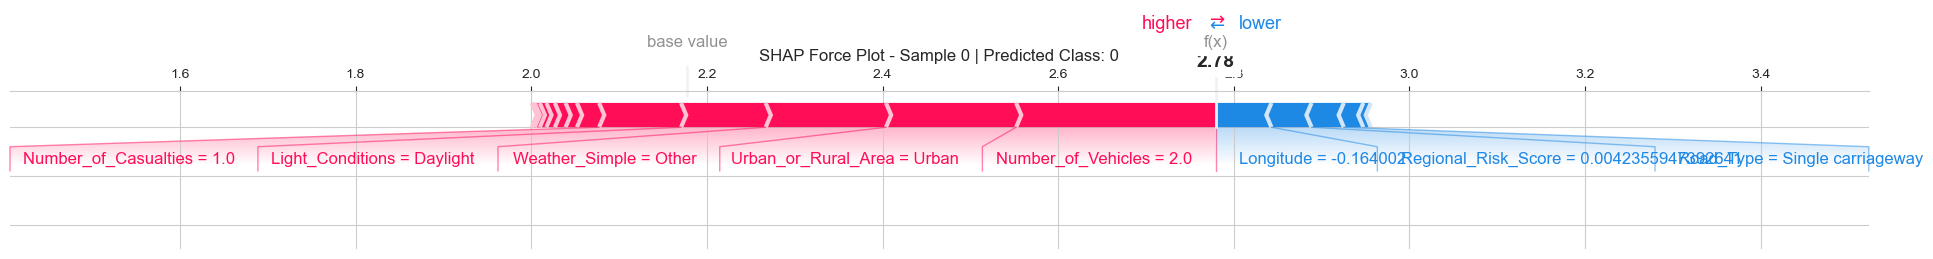


SHAP interpretability completed successfully!


In [37]:
# SHAP INTERPRETABILITY FOR CatBoost_Optuna_Tuned
# FIXED FOR MULTICLASS CATBOOST + DIFFERENT SHAP OUTPUT FORMATS

import numpy as np
import shap
import matplotlib.pyplot as plt
import warnings
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

print("Loading CatBoost_Optuna_Tuned model for SHAP analysis...")

# 1. Load saved model
final_model = CatBoostClassifier()
final_model.load_model("CatBoost_Optuna_Tuned.cbm")

print(f"Model loaded successfully! (Trees: {final_model.tree_count_})")

# 2. Use RAW test data
print("Using raw X_test...")
X_test_raw = X_test.copy()

# Optional but nice for labels
try:
    class_names = [str(c) for c in final_model.classes_]
except:
    class_names = ["Slight", "Serious", "Fatal"]

# 3. Build explainer
explainer = shap.TreeExplainer(
    final_model,
    feature_perturbation="tree_path_dependent"
)

print("Computing SHAP values... (this may take some time)")
shap_values = explainer.shap_values(X_test_raw)


# =========================================================
# HELPER: extract SHAP values for one class robustly
# Works for:
# - old SHAP format: list of [n_samples, n_features]
# - new SHAP format: array with shape like
#   (n_samples, n_features, n_classes) OR
#   (n_samples, n_classes, n_features)
# =========================================================
def get_class_shap_values(shap_values, expected_value, class_idx, n_classes):
    # Case 1: old format -> list of arrays
    if isinstance(shap_values, list):
        class_shap = shap_values[class_idx]

    # Case 2: new format -> ndarray
    else:
        sv = np.array(shap_values)

        if sv.ndim == 3:
            # shape: (n_samples, n_features, n_classes)
            if sv.shape[2] == n_classes:
                class_shap = sv[:, :, class_idx]

            # shape: (n_samples, n_classes, n_features)
            elif sv.shape[1] == n_classes:
                class_shap = sv[:, class_idx, :]

            else:
                raise ValueError(f"Unexpected SHAP shape: {sv.shape}")

        elif sv.ndim == 2:
            # already single-output shape
            class_shap = sv

        else:
            raise ValueError(f"Unexpected SHAP shape: {sv.shape}")

    # Expected/base value for this class
    if isinstance(expected_value, (list, np.ndarray)):
        ev = np.array(expected_value).reshape(-1)[class_idx]
    else:
        ev = expected_value

    return class_shap, ev


# =========================================================
# 1. CLASS-SPECIFIC SHAP SUMMARY PLOTS
# For multiclass problems, this is cleaner than passing the raw
# multiclass object directly into summary_plot.
# =========================================================
print("\nGenerating SHAP Summary Plots by class...")

n_classes = len(class_names)

for class_idx, class_name in enumerate(class_names):
    class_shap_values, class_expected_value = get_class_shap_values(
        shap_values=shap_values,
        expected_value=explainer.expected_value,
        class_idx=class_idx,
        n_classes=n_classes
    )

    plt.figure(figsize=(16, 10))
    shap.summary_plot(
        class_shap_values,
        X_test_raw,
        feature_names=list(X_test_raw.columns),
        max_display=20,
        show=False
    )
    plt.title(f"SHAP Summary Plot - Class: {class_name}")
    plt.tight_layout()
    plt.show()


# =========================================================
# 2. SHAP FORCE PLOT FOR ONE SAMPLE
# Must explain ONE sample for ONE class.
# Best practice: explain the predicted class for that sample.
# =========================================================
print("\nGenerating SHAP Force Plot for one sample...")

sample_idx = 0  # change this to inspect another accident

# Get predicted class index for this sample
sample_proba = final_model.predict_proba(X_test_raw.iloc[[sample_idx]])
pred_class_idx = int(np.argmax(sample_proba, axis=1)[0])
pred_class_name = class_names[pred_class_idx]

# Extract SHAP values for predicted class
class_shap_values, class_expected_value = get_class_shap_values(
    shap_values=shap_values,
    expected_value=explainer.expected_value,
    class_idx=pred_class_idx,
    n_classes=n_classes
)

# One sample, one class -> 1D SHAP vector
force_shap_values = class_shap_values[sample_idx]

# Use raw feature values for that one sample
sample_features = X_test_raw.iloc[sample_idx].values

plt.figure(figsize=(18, 4))
shap.force_plot(
    base_value=class_expected_value,
    shap_values=force_shap_values,
    features=sample_features,
    feature_names=list(X_test_raw.columns),
    matplotlib=True,
    show=False
)
plt.title(f"SHAP Force Plot - Sample {sample_idx} | Predicted Class: {pred_class_name}")
plt.tight_layout()
plt.show()

print("\nSHAP interpretability completed successfully!")

## Save the Graphs:

In [40]:
# SAVE SHAP INTERPRETABILITY GRAPHS FOR CatBoost_Optuna_Tuned

import os
import numpy as np
import shap
import matplotlib.pyplot as plt
import warnings
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

# =========================================================
# CONFIG
# =========================================================
MODEL_PATH = "CatBoost_Optuna_Tuned.cbm"
SAVE_DIR = "shap_outputs"
SAMPLE_IDX = 0   # sample to explain locally

os.makedirs(SAVE_DIR, exist_ok=True)

print("Loading CatBoost_Optuna_Tuned model...")
final_model = CatBoostClassifier()
final_model.load_model(MODEL_PATH)
print(f"Model loaded successfully! Trees: {final_model.tree_count_}")

# Use raw test data
X_test_raw = X_test.copy()

# Optional class names
try:
    class_names = [str(c) for c in final_model.classes_]
except:
    class_names = ["Slight", "Serious", "Fatal"]

# =========================================================
# SHAP EXPLAINER
# =========================================================
print("Building SHAP explainer...")
explainer = shap.TreeExplainer(
    final_model,
    feature_perturbation="tree_path_dependent"
)

print("Computing SHAP values...")
shap_values = explainer.shap_values(X_test_raw)

# =========================================================
# HELPER
# =========================================================
def get_class_shap_values(shap_values, expected_value, class_idx, n_classes):
    if isinstance(shap_values, list):
        class_shap = shap_values[class_idx]
    else:
        sv = np.array(shap_values)

        if sv.ndim == 3:
            if sv.shape[2] == n_classes:      # (n_samples, n_features, n_classes)
                class_shap = sv[:, :, class_idx]
            elif sv.shape[1] == n_classes:    # (n_samples, n_classes, n_features)
                class_shap = sv[:, class_idx, :]
            else:
                raise ValueError(f"Unexpected SHAP shape: {sv.shape}")
        elif sv.ndim == 2:
            class_shap = sv
        else:
            raise ValueError(f"Unexpected SHAP shape: {sv.shape}")

    if isinstance(expected_value, (list, np.ndarray)):
        ev = np.array(expected_value).reshape(-1)[class_idx]
    else:
        ev = expected_value

    return class_shap, ev

# =========================================================
# 1. SAVE CLASS-WISE SUMMARY PLOTS
# =========================================================
print("\nSaving SHAP summary plots...")
n_classes = len(class_names)

for class_idx, class_name in enumerate(class_names):
    class_shap_values, class_expected_value = get_class_shap_values(
        shap_values=shap_values,
        expected_value=explainer.expected_value,
        class_idx=class_idx,
        n_classes=n_classes
    )

    plt.figure(figsize=(16, 10))
    shap.summary_plot(
        class_shap_values,
        X_test_raw,
        feature_names=list(X_test_raw.columns),
        max_display=20,
        show=False
    )
    plt.title(f"SHAP Summary Plot - Class: {class_name}")
    plt.tight_layout()

    summary_path = os.path.join(SAVE_DIR, f"shap_summary_{class_name}.png")
    plt.savefig(summary_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved: {summary_path}")

# =========================================================
# 2. SAVE FORCE PLOT AS PNG
# =========================================================
print("\nSaving SHAP force plot as PNG...")

sample_proba = final_model.predict_proba(X_test_raw.iloc[[SAMPLE_IDX]])
pred_class_idx = int(np.argmax(sample_proba, axis=1)[0])
pred_class_name = class_names[pred_class_idx]

class_shap_values, class_expected_value = get_class_shap_values(
    shap_values=shap_values,
    expected_value=explainer.expected_value,
    class_idx=pred_class_idx,
    n_classes=n_classes
)

force_shap_values = class_shap_values[SAMPLE_IDX]
sample_features_series = X_test_raw.iloc[SAMPLE_IDX]
sample_features_array = sample_features_series.values

plt.figure(figsize=(20, 4))
shap.force_plot(
    base_value=class_expected_value,
    shap_values=force_shap_values,
    features=sample_features_array,
    feature_names=list(X_test_raw.columns),
    matplotlib=True,
    show=False
)
plt.title(f"SHAP Force Plot - Sample {SAMPLE_IDX} | Predicted Class: {pred_class_name}")
plt.tight_layout()

force_png_path = os.path.join(SAVE_DIR, f"shap_force_sample_{SAMPLE_IDX}_{pred_class_name}.png")
plt.savefig(force_png_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"Saved: {force_png_path}")

# =========================================================
# 3. OPTIONAL: SAVE INTERACTIVE FORCE PLOT AS HTML
# =========================================================
print("\nSaving interactive SHAP force plot as HTML...")

force_html = shap.force_plot(
    base_value=class_expected_value,
    shap_values=force_shap_values,
    features=sample_features_series,
    feature_names=list(X_test_raw.columns)
)

force_html_path = os.path.join(SAVE_DIR, f"shap_force_sample_{SAMPLE_IDX}_{pred_class_name}.html")
shap.save_html(force_html_path, force_html)

print(f"Saved: {force_html_path}")

print("\nAll SHAP graphs saved successfully!")

Loading CatBoost_Optuna_Tuned model...
Model loaded successfully! Trees: 500
Building SHAP explainer...
Computing SHAP values...

Saving SHAP summary plots...
Saved: shap_outputs\shap_summary_0.png
Saved: shap_outputs\shap_summary_1.png
Saved: shap_outputs\shap_summary_2.png

Saving SHAP force plot as PNG...
Saved: shap_outputs\shap_force_sample_0_0.png

Saving interactive SHAP force plot as HTML...
Saved: shap_outputs\shap_force_sample_0_0.html

All SHAP graphs saved successfully!


In [42]:
# All SHAP Plots:

In [44]:
# SAVE ALL SHAP INTERPRETABILITY PLOTS FOR MULTICLASS CATBOOST

import os
import numpy as np
import shap
import matplotlib.pyplot as plt
import warnings
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

# =========================================================
# CONFIG
# =========================================================
MODEL_PATH = "CatBoost_Optuna_Tuned.cbm"
SAVE_DIR = "shap_outputs"

SAMPLE_IDX = 0                  # local explanation sample
TOP_N_DEPENDENCE = 5            # number of dependence plots per class
MAX_DISPLAY_SUMMARY = 20        # top features shown in summary plots
USE_SAMPLE_FOR_SHAP = False     # set True if SHAP is too slow
SHAP_SAMPLE_SIZE = 1000         # used only if USE_SAMPLE_FOR_SHAP=True

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "summary_beeswarm"), exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "summary_bar"), exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "dependence"), exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "waterfall"), exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "force_png"), exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "force_html"), exist_ok=True)

# =========================================================
# LOAD MODEL
# =========================================================
print("Loading model...")
final_model = CatBoostClassifier()
final_model.load_model(MODEL_PATH)
print(f"Model loaded successfully! Trees: {final_model.tree_count_}")

# =========================================================
# DATA
# Assumes X_test already exists in your notebook
# =========================================================
X_test_raw = X_test.copy()

if USE_SAMPLE_FOR_SHAP and len(X_test_raw) > SHAP_SAMPLE_SIZE:
    X_shap = X_test_raw.sample(SHAP_SAMPLE_SIZE, random_state=42).copy()
    print(f"Using SHAP sample: {X_shap.shape}")
else:
    X_shap = X_test_raw.copy()
    print(f"Using full X_test for SHAP: {X_shap.shape}")

# Optional class names
try:
    class_names = [str(c) for c in final_model.classes_]
except:
    class_names = ["Slight", "Serious", "Fatal"]

# =========================================================
# SHAP EXPLAINER
# =========================================================
print("Building SHAP explainer...")
explainer = shap.TreeExplainer(
    final_model,
    feature_perturbation="tree_path_dependent"
)

print("Computing SHAP values...")
shap_values = explainer.shap_values(X_shap)

# =========================================================
# HELPERS
# =========================================================
def safe_filename(text):
    return str(text).replace("/", "_").replace("\\", "_").replace(" ", "_")

def get_class_shap_values(shap_values, expected_value, class_idx, n_classes):
    """
    Handles both:
    1) old SHAP format: list of arrays [n_classes][n_samples, n_features]
    2) new SHAP format: ndarray
       - (n_samples, n_features, n_classes)
       - (n_samples, n_classes, n_features)
    """
    if isinstance(shap_values, list):
        class_shap = shap_values[class_idx]
    else:
        sv = np.array(shap_values)

        if sv.ndim == 3:
            if sv.shape[2] == n_classes:      # (n_samples, n_features, n_classes)
                class_shap = sv[:, :, class_idx]
            elif sv.shape[1] == n_classes:    # (n_samples, n_classes, n_features)
                class_shap = sv[:, class_idx, :]
            else:
                raise ValueError(f"Unexpected SHAP shape: {sv.shape}")
        elif sv.ndim == 2:
            class_shap = sv
        else:
            raise ValueError(f"Unexpected SHAP shape: {sv.shape}")

    if isinstance(expected_value, (list, np.ndarray)):
        ev = np.array(expected_value).reshape(-1)[class_idx]
    else:
        ev = expected_value

    return np.array(class_shap), ev

def get_top_features_by_mean_abs_shap(class_shap_values, feature_names, top_n=5):
    mean_abs = np.abs(class_shap_values).mean(axis=0)
    order = np.argsort(mean_abs)[::-1]
    top_idx = order[:top_n]
    return [feature_names[i] for i in top_idx]

# =========================================================
# 1. SAVE SUMMARY PLOTS
# =========================================================
print("\nSaving summary plots...")
n_classes = len(class_names)
feature_names = list(X_shap.columns)

for class_idx, class_name in enumerate(class_names):
    class_name_safe = safe_filename(class_name)

    class_shap_values, class_expected_value = get_class_shap_values(
        shap_values=shap_values,
        expected_value=explainer.expected_value,
        class_idx=class_idx,
        n_classes=n_classes
    )

    # -------------------------
    # A. Beeswarm summary plot
    # -------------------------
    plt.figure(figsize=(16, 10))
    shap.summary_plot(
        class_shap_values,
        X_shap,
        feature_names=feature_names,
        max_display=MAX_DISPLAY_SUMMARY,
        show=False
    )
    plt.title(f"SHAP Beeswarm Summary Plot - Class: {class_name}")
    plt.tight_layout()

    beeswarm_path = os.path.join(
        SAVE_DIR, "summary_beeswarm", f"shap_beeswarm_{class_name_safe}.png"
    )
    plt.savefig(beeswarm_path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved: {beeswarm_path}")

    # -------------------------
    # B. Bar summary plot
    # -------------------------
    plt.figure(figsize=(16, 10))
    shap.summary_plot(
        class_shap_values,
        X_shap,
        feature_names=feature_names,
        plot_type="bar",
        max_display=MAX_DISPLAY_SUMMARY,
        show=False
    )
    plt.title(f"SHAP Bar Summary Plot - Class: {class_name}")
    plt.tight_layout()

    bar_path = os.path.join(
        SAVE_DIR, "summary_bar", f"shap_bar_{class_name_safe}.png"
    )
    plt.savefig(bar_path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved: {bar_path}")

# =========================================================
# 2. SAVE DEPENDENCE PLOTS FOR TOP FEATURES OF EACH CLASS
# =========================================================
print("\nSaving dependence plots...")

for class_idx, class_name in enumerate(class_names):
    class_name_safe = safe_filename(class_name)

    class_shap_values, _ = get_class_shap_values(
        shap_values=shap_values,
        expected_value=explainer.expected_value,
        class_idx=class_idx,
        n_classes=n_classes
    )

    top_features = get_top_features_by_mean_abs_shap(
        class_shap_values,
        feature_names=feature_names,
        top_n=TOP_N_DEPENDENCE
    )

    for feat in top_features:
        plt.figure(figsize=(10, 6))
        shap.dependence_plot(
            ind=feat,
            shap_values=class_shap_values,
            features=X_shap,
            feature_names=feature_names,
            interaction_index="auto",
            show=False
        )
        plt.title(f"SHAP Dependence Plot - {class_name} - {feat}")
        plt.tight_layout()

        dep_path = os.path.join(
            SAVE_DIR,
            "dependence",
            f"shap_dependence_{class_name_safe}_{safe_filename(feat)}.png"
        )
        plt.savefig(dep_path, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"Saved: {dep_path}")

# =========================================================
# 3. SAVE LOCAL PLOTS FOR ONE SAMPLE
# Uses predicted class for that sample
# =========================================================
print("\nSaving local explanation plots...")

if SAMPLE_IDX >= len(X_shap):
    raise IndexError(f"SAMPLE_IDX={SAMPLE_IDX} is out of range for X_shap with length {len(X_shap)}")

sample_row_df = X_shap.iloc[[SAMPLE_IDX]]
sample_row_series = X_shap.iloc[SAMPLE_IDX]

sample_proba = final_model.predict_proba(sample_row_df)
pred_class_idx = int(np.argmax(sample_proba, axis=1)[0])
pred_class_name = class_names[pred_class_idx]
pred_class_name_safe = safe_filename(pred_class_name)

class_shap_values, class_expected_value = get_class_shap_values(
    shap_values=shap_values,
    expected_value=explainer.expected_value,
    class_idx=pred_class_idx,
    n_classes=n_classes
)

force_shap_values = class_shap_values[SAMPLE_IDX]

# -------------------------
# A. Waterfall plot
# -------------------------
waterfall_explanation = shap.Explanation(
    values=force_shap_values,
    base_values=class_expected_value,
    data=sample_row_series.values,
    feature_names=feature_names
)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(waterfall_explanation, max_display=20, show=False)
plt.tight_layout()

waterfall_path = os.path.join(
    SAVE_DIR,
    "waterfall",
    f"shap_waterfall_sample_{SAMPLE_IDX}_{pred_class_name_safe}.png"
)
plt.savefig(waterfall_path, dpi=300, bbox_inches="tight")
plt.close()
print(f"Saved: {waterfall_path}")

# -------------------------
# B. Force plot as PNG
# -------------------------
plt.figure(figsize=(20, 4))
shap.force_plot(
    base_value=class_expected_value,
    shap_values=force_shap_values,
    features=sample_row_series.values,
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.title(f"SHAP Force Plot - Sample {SAMPLE_IDX} | Predicted Class: {pred_class_name}")
plt.tight_layout()

force_png_path = os.path.join(
    SAVE_DIR,
    "force_png",
    f"shap_force_sample_{SAMPLE_IDX}_{pred_class_name_safe}.png"
)
plt.savefig(force_png_path, dpi=300, bbox_inches="tight")
plt.close()
print(f"Saved: {force_png_path}")

# -------------------------
# C. Interactive force plot as HTML
# -------------------------
force_html = shap.force_plot(
    base_value=class_expected_value,
    shap_values=force_shap_values,
    features=sample_row_series,
    feature_names=feature_names
)

force_html_path = os.path.join(
    SAVE_DIR,
    "force_html",
    f"shap_force_sample_{SAMPLE_IDX}_{pred_class_name_safe}.html"
)
shap.save_html(force_html_path, force_html)
print(f"Saved: {force_html_path}")

print("\nAll SHAP plots saved successfully!")

Loading model...
Model loaded successfully! Trees: 500
Using full X_test for SHAP: (144392, 18)
Building SHAP explainer...
Computing SHAP values...

Saving summary plots...
Saved: shap_outputs\summary_beeswarm\shap_beeswarm_0.png
Saved: shap_outputs\summary_bar\shap_bar_0.png
Saved: shap_outputs\summary_beeswarm\shap_beeswarm_1.png
Saved: shap_outputs\summary_bar\shap_bar_1.png
Saved: shap_outputs\summary_beeswarm\shap_beeswarm_2.png
Saved: shap_outputs\summary_bar\shap_bar_2.png

Saving dependence plots...
Saved: shap_outputs\dependence\shap_dependence_0_Number_of_Vehicles.png
Saved: shap_outputs\dependence\shap_dependence_0_Urban_or_Rural_Area.png
Saved: shap_outputs\dependence\shap_dependence_0_Number_of_Casualties.png
Saved: shap_outputs\dependence\shap_dependence_0_Light_Conditions.png
Saved: shap_outputs\dependence\shap_dependence_0_Road_Type.png
Saved: shap_outputs\dependence\shap_dependence_1_Urban_or_Rural_Area.png
Saved: shap_outputs\dependence\shap_dependence_1_Number_of_Veh

# identify geographic severity hotspots from your saved model

Top 20 geographic severity hotspots:


,lat_bin,lon_bin,accidents,mean_hotspot_score,total_hotspot_score,mean_serious_prob,mean_fatal_prob,latitude,longitude,priority_score
0,53.80,-0.56,5,0.260827,1.304133,0.319283,0.101185,53.803837,-0.562250,0.607538
1,52.06,0.04,6,0.260113,1.560678,0.273330,0.123448,52.063133,0.040872,0.607395
2,51.51,-0.13,603,0.102422,61.760448,0.184540,0.010152,51.509829,-0.129896,0.598600
3,54.47,-0.77,6,0.248824,1.492944,0.365495,0.066076,54.466234,-0.771731,0.578349
4,54.26,-1.35,5,0.245489,1.227445,0.299499,0.095740,54.258370,-1.350903,0.568175
5,50.97,0.48,6,0.241629,1.449772,0.334012,0.074623,50.967592,0.478909,0.559836
6,51.01,-1.25,5,0.242157,1.210786,0.339404,0.072455,51.014722,-1.251974,0.559624
7,56.38,-3.53,5,0.239549,1.197743,0.239643,0.119727,56.375932,-3.528038,0.552929
8,53.95,-1.00,5,0.236477,1.182383,0.324319,0.074317,53.951802,-1.000862,0.545044
9,56.72,-2.75,5,0.235390,1.176952,0.248301,0.111240,56.723357,-2.749174,0.542257


Saved: geographic_severity_hotspots.csv


<Figure size 2000x400 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

...

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 2000x400 with 0 Axes>

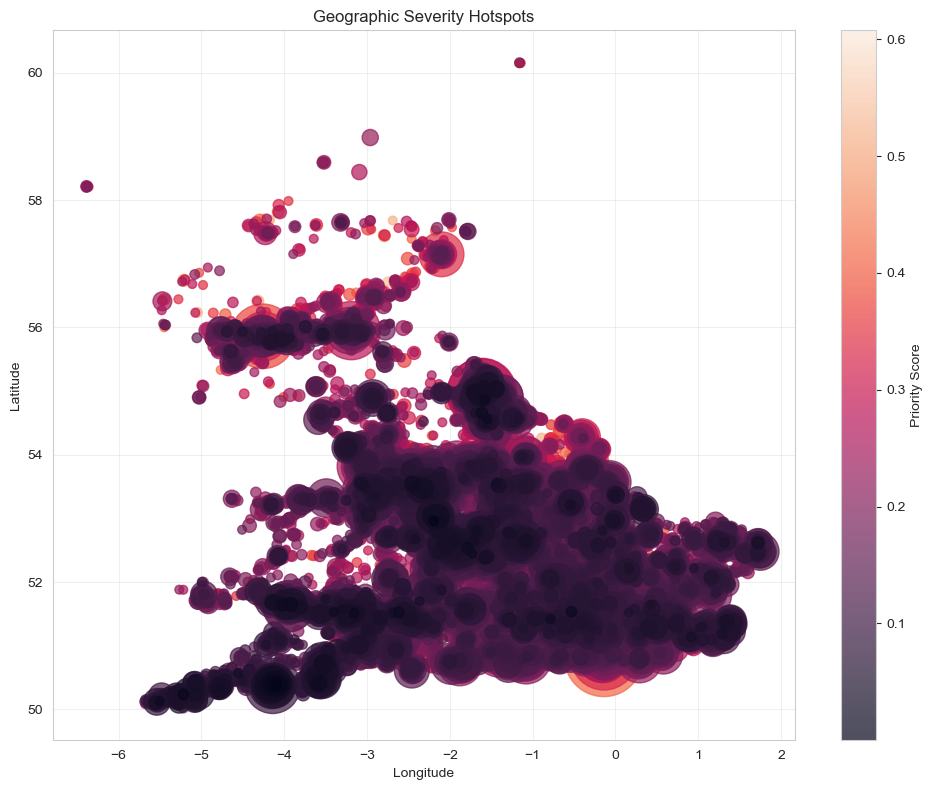

In [48]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
DATA_PATH = "cleaned_data.csv"
MODEL_PATH = "CatBoost_Optuna_Tuned.cbm"   # or .pkl

LAT_COL = "Latitude"
LON_COL = "Longitude"
TARGET_COL = "Accident_Severity"

GRID_DECIMALS = 2      # 2 ~ moderate spatial cell size
MIN_ACCIDENTS = 5      # ignore cells with too few accidents

# weights for hotspot severity score
SERIOUS_WEIGHT = 0.5
FATAL_WEIGHT = 1.0

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(DATA_PATH)

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

if LAT_COL not in df.columns or LON_COL not in df.columns:
    raise ValueError("Latitude/Longitude columns not found.")

df_features = df.drop(columns=[TARGET_COL], errors="ignore").copy()

# =========================================================
# FEATURE ENGINEERING
# =========================================================
def add_cyclical_features(frame):
    frame = frame.copy()

    if "acc_month" in frame.columns:
        frame["acc_month_sin"] = np.sin(2 * np.pi * frame["acc_month"] / 12)
        frame["acc_month_cos"] = np.cos(2 * np.pi * frame["acc_month"] / 12)

    if "acc_dayofweek" in frame.columns:
        frame["acc_dayofweek_sin"] = np.sin(2 * np.pi * frame["acc_dayofweek"] / 7)
        frame["acc_dayofweek_cos"] = np.cos(2 * np.pi * frame["acc_dayofweek"] / 7)

    return frame

X = add_cyclical_features(df_features)

# =========================================================
# LOAD MODEL
# =========================================================
if MODEL_PATH.endswith(".cbm"):
    model = CatBoostClassifier()
    model.load_model(MODEL_PATH)
elif MODEL_PATH.endswith(".pkl"):
    model = joblib.load(MODEL_PATH)
else:
    raise ValueError("MODEL_PATH must end with .cbm or .pkl")

expected_cols = list(model.feature_names_)

# Drop raw month/day if model expects only cyclical versions
for col in ["acc_month", "acc_dayofweek"]:
    if col in X.columns and col not in expected_cols:
        X = X.drop(columns=[col])

missing_cols = [c for c in expected_cols if c not in X.columns]
if missing_cols:
    raise ValueError(f"Missing model columns: {missing_cols}")

extra_cols = [c for c in X.columns if c not in expected_cols]
if extra_cols:
    X = X.drop(columns=extra_cols)

X = X[expected_cols].copy()

# =========================================================
# PREDICT PROBABILITIES
# =========================================================
proba = model.predict_proba(X)

# class names from model
try:
    class_names = [str(c) for c in model.classes_]
except:
    class_names = ["Slight", "Serious", "Fatal"]

proba_df = pd.DataFrame(proba, columns=[f"prob_{c}" for c in class_names])

# find serious/fatal columns safely
if "Serious" in class_names:
    serious_col = "prob_Serious"
else:
    serious_col = proba_df.columns[1]

if "Fatal" in class_names:
    fatal_col = "prob_Fatal"
else:
    fatal_col = proba_df.columns[2]

# =========================================================
# BUILD HOTSPOT SCORING TABLE
# =========================================================
risk_df = df[[LAT_COL, LON_COL]].copy()
risk_df = pd.concat([risk_df.reset_index(drop=True), proba_df.reset_index(drop=True)], axis=1)

risk_df["hotspot_score"] = (
    SERIOUS_WEIGHT * risk_df[serious_col] +
    FATAL_WEIGHT * risk_df[fatal_col]
)

# create geographic bins
risk_df["lat_bin"] = risk_df[LAT_COL].round(GRID_DECIMALS)
risk_df["lon_bin"] = risk_df[LON_COL].round(GRID_DECIMALS)

# aggregate by cell
hotspots = (
    risk_df
    .groupby(["lat_bin", "lon_bin"], as_index=False)
    .agg(
        accidents=("hotspot_score", "size"),
        mean_hotspot_score=("hotspot_score", "mean"),
        total_hotspot_score=("hotspot_score", "sum"),
        mean_serious_prob=(serious_col, "mean"),
        mean_fatal_prob=(fatal_col, "mean"),
        latitude=(LAT_COL, "mean"),
        longitude=(LON_COL, "mean")
    )
)

# filter sparse cells
hotspots = hotspots[hotspots["accidents"] >= MIN_ACCIDENTS].copy()

# normalize for combined ranking
def minmax(s):
    if s.max() == s.min():
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())

hotspots["priority_score"] = (
    0.6 * minmax(hotspots["mean_hotspot_score"]) +
    0.4 * minmax(hotspots["total_hotspot_score"])
)

hotspots = hotspots.sort_values(
    ["priority_score", "mean_fatal_prob", "accidents"],
    ascending=False
).reset_index(drop=True)

print("Top 20 geographic severity hotspots:")
display(hotspots.head(20))

hotspots.to_csv("geographic_severity_hotspots.csv", index=False)
print("Saved: geographic_severity_hotspots.csv")

# =========================================================
# SIMPLE STATIC VISUALIZATION
# =========================================================
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    hotspots["longitude"],
    hotspots["latitude"],
    c=hotspots["priority_score"],
    s=hotspots["accidents"] * 8,
    alpha=0.7
)

plt.colorbar(scatter, label="Priority Score")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Severity Hotspots")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Geographic Severity Hotspot Mapping

In [53]:
# GEOGRAPHIC SEVERITY HOTSPOT MAPPING
# Using saved CatBoost model + Folium
!pip install folium

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
from catboost import CatBoostClassifier

import folium
from folium.plugins import HeatMap, MarkerCluster


# =========================================================
# CONFIG
# =========================================================
DATA_PATH = "cleaned_data.csv"
MODEL_PATH = "CatBoost_Optuna_Tuned.cbm"   # or .pkl

TARGET_COL = "Accident_Severity"
LAT_COL = "Latitude"
LON_COL = "Longitude"

YEAR_FILTER = None        # e.g. 2022 or None for all data
GRID_DECIMALS = 2         # 2 = moderate aggregation grid
MIN_ACCIDENTS = 5         # minimum records per cell to keep

SERIOUS_WEIGHT = 0.5
FATAL_WEIGHT = 1.0

OUTPUT_POINT_MAP = "uk_severity_point_risk_map.html"
OUTPUT_HOTSPOT_MAP = "uk_severity_hotspot_circle_map.html"
OUTPUT_HEATMAP = "uk_severity_heatmap.html"
OUTPUT_HOTSPOT_TABLE = "uk_geographic_severity_hotspots.csv"

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(DATA_PATH)

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

if LAT_COL not in df.columns or LON_COL not in df.columns:
    raise ValueError("Latitude/Longitude columns are missing from the dataset.")

# Optional year filtering
if YEAR_FILTER is not None:
    if "acc_year" not in df.columns:
        raise ValueError("YEAR_FILTER was set, but 'acc_year' is not in the dataset.")
    df = df[df["acc_year"] == YEAR_FILTER].copy()

df = df.dropna(subset=[LAT_COL, LON_COL]).reset_index(drop=True)

print("Data shape after filtering:", df.shape)

# =========================================================
# FEATURE ENGINEERING
# =========================================================
def add_cyclical_features(frame):
    frame = frame.copy()

    if "acc_month" in frame.columns:
        frame["acc_month_sin"] = np.sin(2 * np.pi * frame["acc_month"] / 12)
        frame["acc_month_cos"] = np.cos(2 * np.pi * frame["acc_month"] / 12)

    if "acc_dayofweek" in frame.columns:
        frame["acc_dayofweek_sin"] = np.sin(2 * np.pi * frame["acc_dayofweek"] / 7)
        frame["acc_dayofweek_cos"] = np.cos(2 * np.pi * frame["acc_dayofweek"] / 7)

    return frame

X = df.drop(columns=[TARGET_COL], errors="ignore").copy()
X = add_cyclical_features(X)

# =========================================================
# LOAD MODEL
# =========================================================
if MODEL_PATH.endswith(".cbm"):
    model = CatBoostClassifier()
    model.load_model(MODEL_PATH)
elif MODEL_PATH.endswith(".pkl"):
    model = joblib.load(MODEL_PATH)
else:
    raise ValueError("MODEL_PATH must end with .cbm or .pkl")

expected_cols = list(model.feature_names_)

# Remove raw month/day if model only expects cyclical versions
for col in ["acc_month", "acc_dayofweek"]:
    if col in X.columns and col not in expected_cols:
        X = X.drop(columns=[col])

missing_cols = [c for c in expected_cols if c not in X.columns]
if missing_cols:
    raise ValueError(f"Missing columns required by model: {missing_cols}")

extra_cols = [c for c in X.columns if c not in expected_cols]
if extra_cols:
    X = X.drop(columns=extra_cols)

X = X[expected_cols].copy()

print("Model input shape:", X.shape)

# =========================================================
# PREDICT CLASS PROBABILITIES
# =========================================================
proba = model.predict_proba(X)

try:
    class_names = [str(c) for c in model.classes_]
except:
    class_names = ["Slight", "Serious", "Fatal"]

proba_df = pd.DataFrame(proba, columns=[f"prob_{c}" for c in class_names])

# Safe column mapping
if "Slight" in class_names:
    slight_col = "prob_Slight"
else:
    slight_col = proba_df.columns[0]

if "Serious" in class_names:
    serious_col = "prob_Serious"
else:
    serious_col = proba_df.columns[1]

if "Fatal" in class_names:
    fatal_col = "prob_Fatal"
else:
    fatal_col = proba_df.columns[2]

# predicted class
pred_raw = model.predict(X)
pred_raw = np.array(pred_raw).reshape(-1)

predicted_labels = []
for p in pred_raw:
    try:
        p_int = int(float(p))
        if p_int == 0:
            predicted_labels.append("Slight")
        elif p_int == 1:
            predicted_labels.append("Serious")
        elif p_int == 2:
            predicted_labels.append("Fatal")
        else:
            predicted_labels.append(str(p))
    except:
        predicted_labels.append(str(p))

# =========================================================
# BUILD RISK TABLE
# =========================================================
risk_df = df[[LAT_COL, LON_COL]].copy()

keep_cols = [
    c for c in [
        "acc_year", "acc_month", "acc_dayofweek",
        "Urban_or_Rural_Area", "Road_Type",
        "Light_Conditions", "Road_Surface_Conditions",
        "Weather_Simple", "Number_of_Vehicles",
        "Number_of_Casualties", "Regional_Risk_Score"
    ] if c in df.columns
]

risk_df = pd.concat(
    [
        risk_df.reset_index(drop=True),
        df[keep_cols].reset_index(drop=True),
        proba_df.reset_index(drop=True)
    ],
    axis=1
)

risk_df["Predicted_Severity"] = predicted_labels

risk_df["hotspot_score"] = (
    SERIOUS_WEIGHT * risk_df[serious_col] +
    FATAL_WEIGHT * risk_df[fatal_col]
)

# =========================================================
# GEOGRAPHIC AGGREGATION
# =========================================================
risk_df["lat_bin"] = risk_df[LAT_COL].round(GRID_DECIMALS)
risk_df["lon_bin"] = risk_df[LON_COL].round(GRID_DECIMALS)

hotspots = (
    risk_df
    .groupby(["lat_bin", "lon_bin"], as_index=False)
    .agg(
        accidents=("hotspot_score", "size"),
        mean_hotspot_score=("hotspot_score", "mean"),
        total_hotspot_score=("hotspot_score", "sum"),
        mean_serious_prob=(serious_col, "mean"),
        mean_fatal_prob=(fatal_col, "mean"),
        latitude=(LAT_COL, "mean"),
        longitude=(LON_COL, "mean")
    )
)

hotspots = hotspots[hotspots["accidents"] >= MIN_ACCIDENTS].copy()

def minmax(s):
    if s.max() == s.min():
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())

hotspots["priority_score"] = (
    0.6 * minmax(hotspots["mean_hotspot_score"]) +
    0.4 * minmax(hotspots["total_hotspot_score"])
)

hotspots = hotspots.sort_values(
    ["priority_score", "mean_fatal_prob", "accidents"],
    ascending=False
).reset_index(drop=True)

hotspots.to_csv(OUTPUT_HOTSPOT_TABLE, index=False)

print("\nTop 20 hotspots:")
display(hotspots.head(20))

print(f"Hotspot table saved to: {OUTPUT_HOTSPOT_TABLE}")

# =========================================================
# MAP CENTER
# =========================================================
center_lat = risk_df[LAT_COL].mean()
center_lon = risk_df[LON_COL].mean()

# =========================================================
# 1. POINT-LEVEL RISK MAP
# =========================================================
point_map = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles="CartoDB positron")
marker_cluster = MarkerCluster().add_to(point_map)

for _, row in risk_df.sample(min(len(risk_df), 5000), random_state=42).iterrows():
    score = row["hotspot_score"]

    if score >= 0.60:
        color = "darkred"
    elif score >= 0.35:
        color = "orange"
    else:
        color = "green"

    popup_text = f"""
    <b>Predicted Severity:</b> {row['Predicted_Severity']}<br>
    <b>Hotspot Score:</b> {row['hotspot_score']:.4f}<br>
    <b>P(Serious):</b> {row[serious_col]:.4f}<br>
    <b>P(Fatal):</b> {row[fatal_col]:.4f}<br>
    """

    for col in keep_cols:
        popup_text += f"<b>{col}:</b> {row[col]}<br>"

    folium.CircleMarker(
        location=[row[LAT_COL], row[LON_COL]],
        radius=4,
        color=color,
        fill=True,
        fill_opacity=0.65,
        popup=folium.Popup(popup_text, max_width=350)
    ).add_to(marker_cluster)

point_map.save(OUTPUT_POINT_MAP)
print(f"Saved point risk map: {OUTPUT_POINT_MAP}")

# =========================================================
# 2. AGGREGATED HOTSPOT CIRCLE MAP
# =========================================================
hotspot_map = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles="CartoDB positron")

for _, row in hotspots.iterrows():
    ps = row["priority_score"]

    if ps >= 0.70:
        color = "darkred"
    elif ps >= 0.45:
        color = "orange"
    else:
        color = "blue"

    popup_text = f"""
    <b>Hotspot Rank Score:</b> {row['priority_score']:.4f}<br>
    <b>Accidents in Cell:</b> {int(row['accidents'])}<br>
    <b>Mean Hotspot Score:</b> {row['mean_hotspot_score']:.4f}<br>
    <b>Total Hotspot Score:</b> {row['total_hotspot_score']:.4f}<br>
    <b>Mean P(Serious):</b> {row['mean_serious_prob']:.4f}<br>
    <b>Mean P(Fatal):</b> {row['mean_fatal_prob']:.4f}<br>
    <b>Latitude:</b> {row['latitude']:.5f}<br>
    <b>Longitude:</b> {row['longitude']:.5f}
    """

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=max(5, min(25, row["accidents"] * 0.4)),
        color=color,
        fill=True,
        fill_opacity=0.75,
        popup=folium.Popup(popup_text, max_width=300)
    ).add_to(hotspot_map)

hotspot_map.save(OUTPUT_HOTSPOT_MAP)
print(f"Saved hotspot circle map: {OUTPUT_HOTSPOT_MAP}")

# =========================================================
# 3. HEATMAP
# =========================================================
heat_map = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles="CartoDB positron")

heat_data = hotspots[["latitude", "longitude", "priority_score"]].values.tolist()

HeatMap(
    heat_data,
    radius=18,
    blur=14,
    max_zoom=10
).add_to(heat_map)

heat_map.save(OUTPUT_HEATMAP)
print(f"Saved heatmap: {OUTPUT_HEATMAP}")

print("\nAll hotspot maps created successfully.")


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 2/2 [folium]

Data shape after filtering: (660579, 17)
Model input shape: (660579, 18)

Top 20 hotspots:


,lat_bin,lon_bin,accidents,mean_hotspot_score,total_hotspot_score,mean_serious_prob,mean_fatal_prob,latitude,longitude,priority_score
0,53.80,-0.56,5,0.260827,1.304133,0.319283,0.101185,53.803837,-0.562250,0.607538
1,52.06,0.04,6,0.260113,1.560678,0.273330,0.123448,52.063133,0.040872,0.607395
2,51.51,-0.13,603,0.102422,61.760448,0.184540,0.010152,51.509829,-0.129896,0.598600
3,54.47,-0.77,6,0.248824,1.492944,0.365495,0.066076,54.466234,-0.771731,0.578349
4,54.26,-1.35,5,0.245489,1.227445,0.299499,0.095740,54.258370,-1.350903,0.568175
5,50.97,0.48,6,0.241629,1.449772,0.334012,0.074623,50.967592,0.478909,0.559836
6,51.01,-1.25,5,0.242157,1.210786,0.339404,0.072455,51.014722,-1.251974,0.559624
7,56.38,-3.53,5,0.239549,1.197743,0.239643,0.119727,56.375932,-3.528038,0.552929
8,53.95,-1.00,5,0.236477,1.182383,0.324319,0.074317,53.951802,-1.000862,0.545044
9,56.72,-2.75,5,0.235390,1.176952,0.248301,0.111240,56.723357,-2.749174,0.542257


Hotspot table saved to: uk_geographic_severity_hotspots.csv
Saved point risk map: uk_severity_point_risk_map.html
Saved hotspot circle map: uk_severity_hotspot_circle_map.html
Saved heatmap: uk_severity_heatmap.html

All hotspot maps created successfully.


## 1) What each number on the point map means

In the popup, the map stores:

* the model’s **Predicted Severity**
* **Hotspot Score**
* **P(Serious)**
* **P(Fatal)**
* the raw record fields such as year, month, urban/rural status, road type, light conditions, casualties, vehicles, and regional risk score. The map is centered over the UK at roughly latitude `52.55385`, longitude `-1.43122`, using a CARTO/OpenStreetMap basemap. 

So the “numbering” you see on the point map is mainly the **Hotspot Score** shown inside each popup. It is not a city rank by itself. 

## 2) How the hotspot score was calculated

For each accident row (i), the saved CatBoost model produces class probabilities:

[
P_i(\text{Slight}), ; P_i(\text{Serious}), ; P_i(\text{Fatal})
]

Then the point-level severity hotspot score was defined as:

[
\text{HotspotScore}_i = 0.5 \times P_i(\text{Serious}) + 1.0 \times P_i(\text{Fatal})
]

This means:

* fatal probability gets the **full weight**
* serious probability gets **half weight**
* slight probability is used indirectly because all probabilities sum to 1

The idea is simple: a location should get a larger score if the model thinks that record is more likely to be **serious or fatal**, with fatal carrying more importance.

### Example from your attached file

One popup shows:

* `P(Serious) = 0.0981`
* `P(Fatal) = 0.0057`
* `Hotspot Score = 0.0548`

Check:

[
0.5 \times 0.0981 + 1.0 \times 0.0057 = 0.04905 + 0.0057 = 0.05475 \approx 0.0548
]

That matches the map exactly. 

Another popup shows:

* `P(Serious) = 0.2572`
* `P(Fatal) = 0.0193`
* `Hotspot Score = 0.1479`

Check:

[
0.5 \times 0.2572 + 0.0193 = 0.1286 + 0.0193 = 0.1479
]

Again, exact match. 

A third example in the file shows:

* `P(Serious) = 0.3260`
* `P(Fatal) = 0.0451`
* `Hotspot Score = 0.2081`

Check:

[
0.5 \times 0.3260 + 0.0451 = 0.1630 + 0.0451 = 0.2081
]

So every popup score is being computed the same way. 

## 3) How the color on the point map was assigned

In the point map, each accident point was colored from the point-level score:

* **green** = relatively lower modeled severe-risk
* **orange** = medium modeled severe-risk
* **dark red** = higher modeled severe-risk

In the notebook version, those colors were assigned by thresholding the point-level hotspot score. So color is just a visual shorthand for the formula above.

A key point: this is a **record-level risk display**, not yet a true city or district summary.

## 4) How those points got mapped to cities

They were not mapped to city names directly.

The file stores **latitude and longitude coordinates**, for example:

* `[53.521977, -2.123347]`
* `[51.497792, -0.143425]`
* `[52.468686, -1.869984]`

and places them directly on the Leaflet basemap. That means the city association is currently **visual/geographic**, not administrative. You look at where the point falls on the UK map and infer the nearby city or town from the basemap. 

So the current workflow is:

1. predict severity probabilities for each accident
2. compute a point hotspot score
3. plot that score at the accident’s latitude/longitude
4. let the map reveal which urban area or corridor that point belongs to

That is why the HTML file contains coordinates and popup fields, but not a dedicated “City” variable. 

## 5) Where the actual hotspot ranking comes from

The **point map** is only the first step.

The true hotspot ranking comes from **aggregating many nearby accident points together**. In the notebook, that was done by grouping accidents into geographic cells using rounded latitude and longitude, then calculating cell-level metrics:

[
\text{MeanHotspotScore}*g = \frac{1}{n_g} \sum*{i \in g} \text{HotspotScore}_i
]

[
\text{TotalHotspotScore}*g = \sum*{i \in g} \text{HotspotScore}_i
]

where (g) is a grid cell and (n_g) is the number of accidents in that cell.

Then the final hotspot priority ranking used a combined score:

[
\text{PriorityScore}_g =
0.6 \times \text{MinMax}(\text{MeanHotspotScore}_g)
+
0.4 \times \text{MinMax}(\text{TotalHotspotScore}_g)
]

So:

* **MeanHotspotScore** measures **severity intensity**
* **TotalHotspotScore** measures **severity burden**
* **PriorityScore** combines both

This is the number you should use for hotspot prioritization, not the popup score from a single point.

## 6) What the current map lets you conclude

From the point map, the correct interpretation is:

* a point with a larger hotspot score is a **more severity-concerning accident record**
* a cluster of many medium/high-score points in the same area suggests a **candidate severity hotspot**
* city-level or corridor-level conclusions should only be made **after aggregation**

So if you see many points near the same urban area or road corridor with elevated popup scores, that area is worth further investigation.

